In [1]:
from importlib import reload
import torch
import numpy as np
import time
torch.set_default_dtype(torch.float64)
np.random.seed(2)
device = torch.device("cuda:1" if torch.cuda.is_available() else "cpu")
print(device)
import numpy as np
import sys # Add the module path. Windows and Linux use different path separators; the raw string prevents escape sequences such as \n from being interpreted.
sys.path.append(r"../main_code/2d")
import generate_data,mesh,adaptive_int,visual,matrix_assemble,inverse_solver,mea_2d,net_2d,source_eval,error_general_2d,main
import matplotlib.pyplot as plt
CUDA_LAUNCH_BLOCKING=1

def kidney_curve(x, y, h, k, a):
    """
    Compute the implicit kidney-curve value at the given point (x, y).
    
    Parameters:
    x, y: Input coordinate points.
    h, k: Coordinates of the kidney-curve center used for translation.
    a:    Size parameter of the kidney curve.
    """
    x_shifted = x - h
    y_shifted = y - k
    
    # Avoid issues when a = 0.
    if a == 0:
        a = 1e-9

    # Implicit kidney-curve equation: (x_sh^2 + y_sh^2 - 4a^2)^3 - 108a^4 * y_sh^2 = 0
    term1 = (x_shifted**2 + y_shifted**2 - 4 * a**2)**3
    term2 = 108 * a**4 * y_shifted**2
    return term1 - term2

def Gauss_source(X,x_left,x_right,y_below,y_upper,center,r):
    # 1. Primary Gaussian source (simulated tumor).
    x=X[:,0]
    y=X[:,1]
    src1 = 1.2 * np.exp(-((x-0.3)**2 + (y-0.6)**2)/0.008)
    return src1

def kidney_source(X,x_left,x_right,y_below,y_upper,center,r,h=0.6, k=0.25, s=0.05):
    """Kidney-shaped source function."""
    x = X[:, 0]
    y = X[:, 1]
    # Kidney-shaped source with translation and scaling.
    kidney_src = np.where(kidney_curve(x, y, h, k, s) <= 0, 1.0, 0.0)
    return kidney_src

def elegant_source(X,x_left,x_right,y_below,y_upper,center,r,h=0.6, k=0.25, s=0.05):
    """Improved complex source function."""
    gauss= Gauss_source(X,x_left,x_right,y_below,y_upper,center,r)
    # Kidney-shaped source with translation and scaling.
    kidney_src = kidney_source(X, x_left, x_right, y_below, y_upper, center, r, h, k, s)

    return kidney_src +gauss




cuda:1


In [2]:
def kidney_curve(x, y, h, k, a):
    """
    Compute the implicit kidney-curve value at the given point (x, y).
    
    Parameters:
    x, y: Input coordinate points.
    h, k: Coordinates of the kidney-curve center used for translation.
    a:    Size parameter of the kidney curve.
    """
    x_shifted = x - h
    y_shifted = y - k
    
    # Avoid issues when a = 0.
    if a == 0:
        a = 1e-9

    # Implicit kidney-curve equation: (x_sh^2 + y_sh^2 - 4a^2)^3 - 108a^4 * y_sh^2 = 0
    term1 = (x_shifted**2 + y_shifted**2 - 4 * a**2)**3
    term2 = 108 * a**4 * y_shifted**2
    return term1 - term2

def Gauss_source(X,x_left,x_right,y_below,y_upper,center,r):
    # 1. Primary Gaussian source (simulated tumor).
    x=X[:,0]
    y=X[:,1]
    src1 = 1.2 * np.exp(-((x-0.3)**2 + (y-0.6)**2)/0.008)
    return src1

def kidney_source(X,x_left,x_right,y_below,y_upper,center,r,h=0.6, k=0.25, s=0.05):
    """Kidney-shaped source function."""
    x = X[:, 0]
    y = X[:, 1]
    # Kidney-shaped source with translation and scaling.
    kidney_src = np.where(kidney_curve(x, y, h, k, s) <= 0, 1.0, 0.0)
    return kidney_src

def elegant_source(X,x_left,x_right,y_below,y_upper,center,r,h=0.6, k=0.25, s=0.05):
    """Improved complex source function."""
    gauss= Gauss_source(X,x_left,x_right,y_below,y_upper,center,r)
    # Kidney-shaped source with translation and scaling.
    kidney_src = kidney_source(X, x_left, x_right, y_below, y_upper, center, r, h, k, s)

    return kidney_src +gauss



In [3]:
import pickle

with open("./noise=5%/cells_store_last.pkl", "rb") as f:
    cells_store=pickle.load(f)
x = np.linspace(0, 1, 301)
y = np.linspace(0, 1, 301)
X, Y = np.meshgrid(x, y,indexing='ij')
samples=np.vstack((X.ravel(),Y.ravel())).T
center=np.array([[-0.06,0],[0.08,0]])
r=0.06
S_num_proce=np.load("./noise=5%/S_num_store_ada.npy")
S_num_last=S_num_proce[-1]
# Create data


In [4]:
kidney_bound=np.load("./noise=5%/kidney_num.npy")

In [5]:
import visual
reload(visual)

v = visual.GridMeshVisualizer()
single_figsize = (10, 8)
single_xlim = (0.0, 1.0)
single_ylim = (0.0, 1.0)

fig1, ax1 = plt.subplots(1, 1, figsize=single_figsize)
fig1 = v._plot_single_mesh(
    fig1,
    ax1,
    cells_store,
    S_num=S_num_last,
    points=samples,
    x_range=single_xlim,
    y_range=single_ylim,
    save_path=None,
    style="kidney",
)

In [6]:
import visual
reload(visual)

fig2, ax2 = plt.subplots(1, 1, figsize=single_figsize)
fig2 = v._plot_single_mesh(
    fig2,
    ax2,
    cells_store,
    x_range=single_xlim,
    y_range=single_ylim,
    save_path=None,
    style="kidney",
)

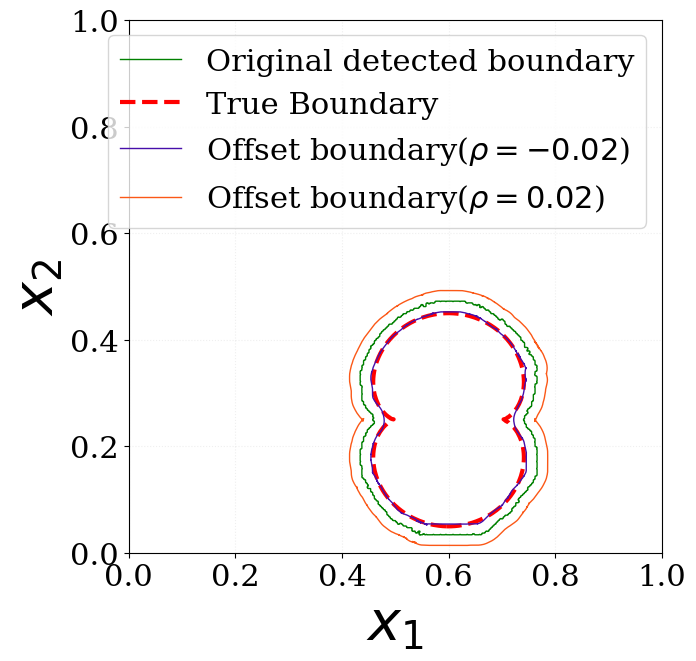

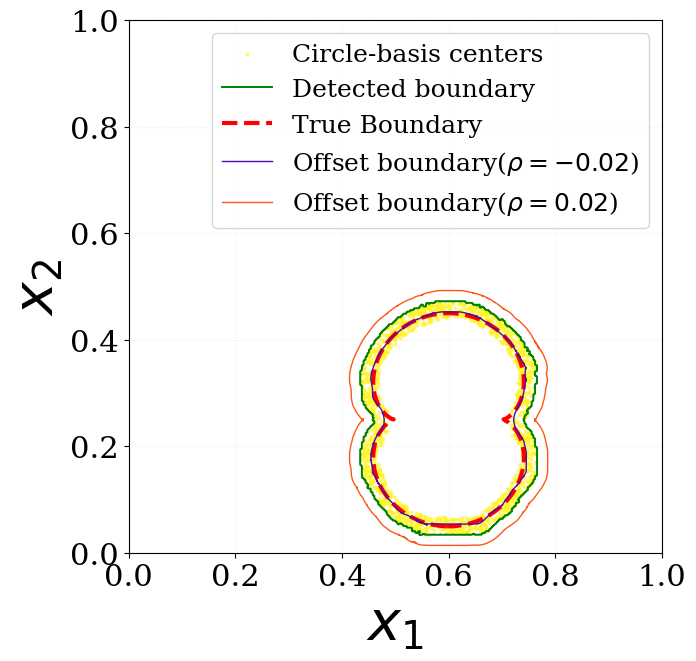

In [7]:
import visual
reload(visual)

fig3, ax3 = plt.subplots(1, 1, figsize=single_figsize)
fig3 = v._scale(fig3, ax3, kidney_bound)

fig_combo = v.plot_scale_and_local_basis(
    kidney_bound,
    noise_dir="./noise=5%",
    output_filename="scale_and_local_basis.pdf",
)
plt.show()

In [8]:
# Save the three single-panel PDFs with the same page size and margins.
def _save_fixed_single_panel(fig, filename):
    fig.set_size_inches(*single_figsize, forward=True)
    fig.subplots_adjust(left=0.16, right=0.96, bottom=0.18, top=0.96)
    for ax in fig.axes:
        # Do not touch colorbar axes; only fix the main x1-x2 panel.
        if ax.get_xlabel().strip() == "$x_1$" or ax.get_ylabel().strip() == "$x_2$":
            ax.set_xlim(*single_xlim)
            ax.set_ylim(*single_ylim)
            ax.set_aspect("equal", adjustable="box")
    fig.savefig(filename, dpi=300)

_save_fixed_single_panel(fig1, "./noise=5%/kidney_value.pdf")
_save_fixed_single_panel(fig2, "./noise=5%/kidney_mesh.pdf")
_save_fixed_single_panel(fig3, "./noise=5%/scale_boundary.pdf")

Plot saved as ./noise=5%/S_true.pdf


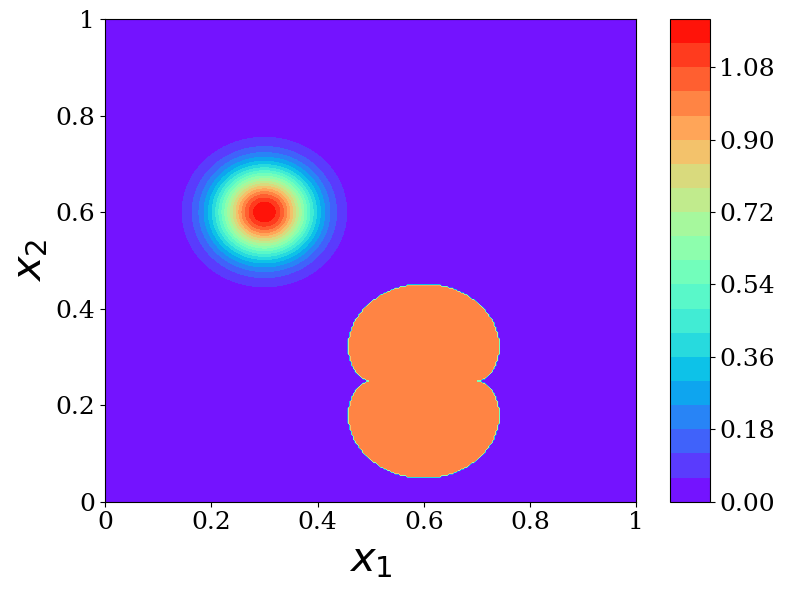

Plot saved as ./noise=5%/S_num_last.pdf


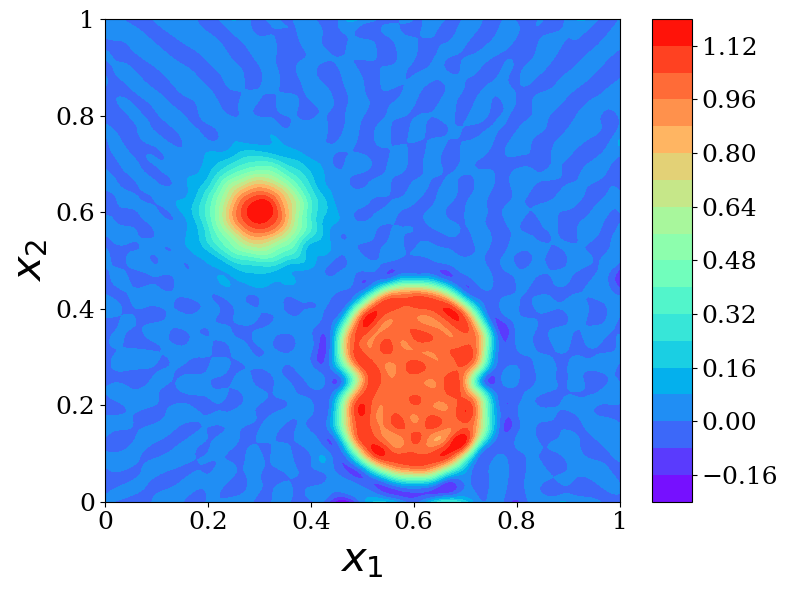

Plot saved as ./noise=5%/abs_S.pdf


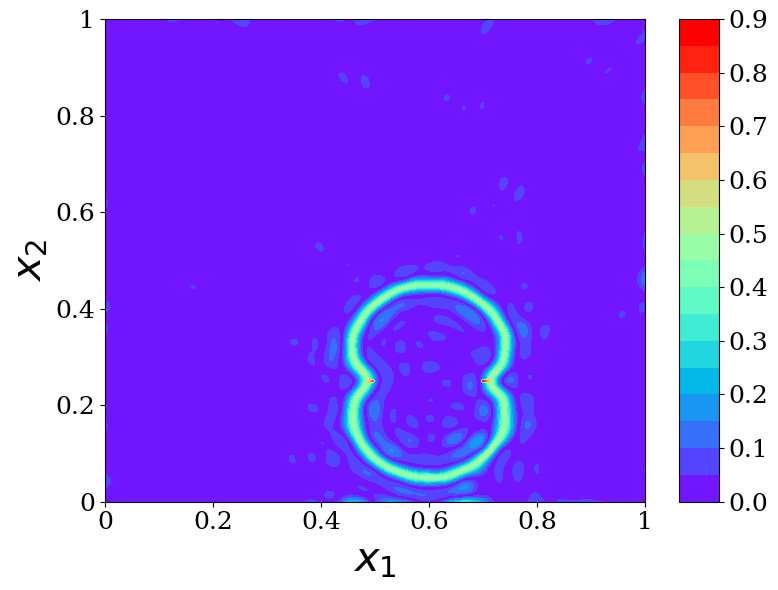

In [9]:
reload(visual)
S_num_proce=np.load("./noise=5%/S_num_store_ada.npy")
S_num_last=S_num_proce[-1]
# Create data

S_true=elegant_source(samples,[],[],[],[],center,r).reshape(len(x),len(y))
output_dictionary="./noise=5%/"
visual.draw(X,Y,S_true,output_dictionary,"S_true.pdf")
visual.draw(X,Y,S_num_last,output_dictionary,"S_num_last.pdf")
visual.draw(X,Y,np.abs(S_true-S_num_last),output_dictionary,"abs_S.pdf")

Plot saved as ./noise=5%/S_true.pdf


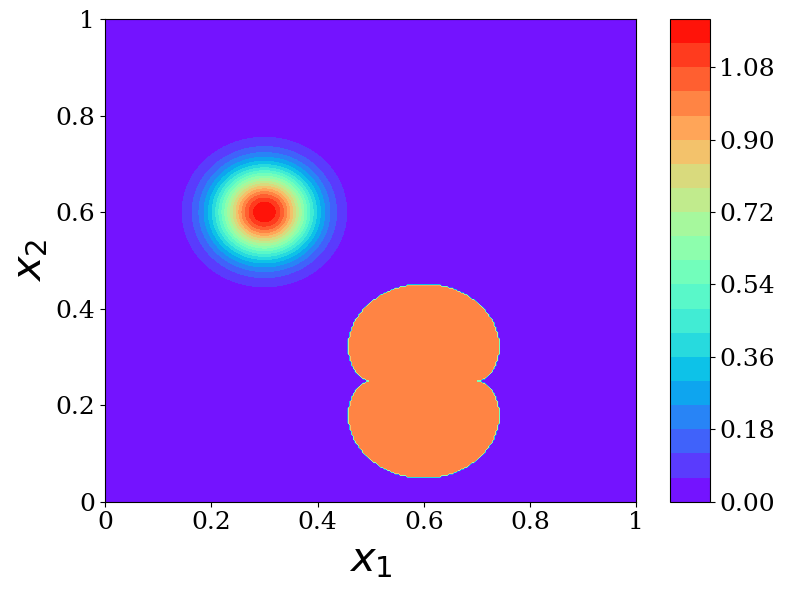

Plot saved as ./noise=5%/S_num.pdf


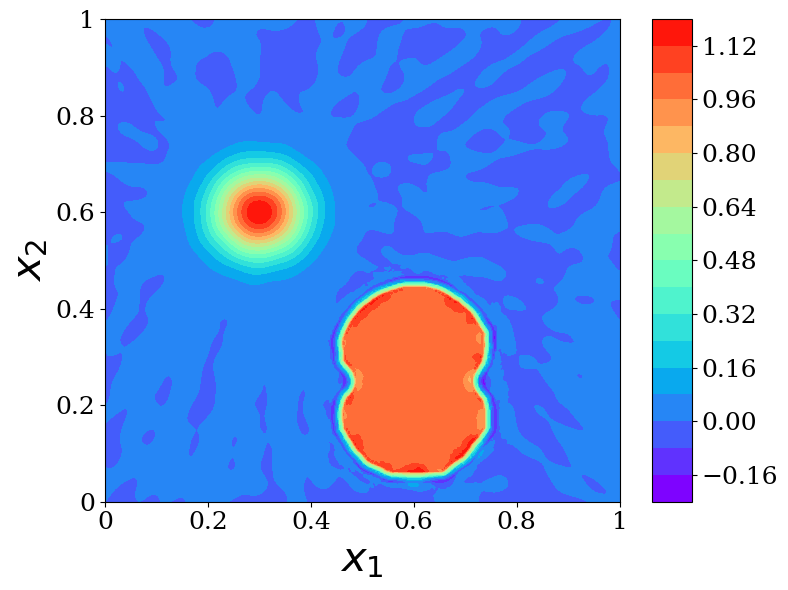

Plot saved as ./noise=5%/abs_S.pdf


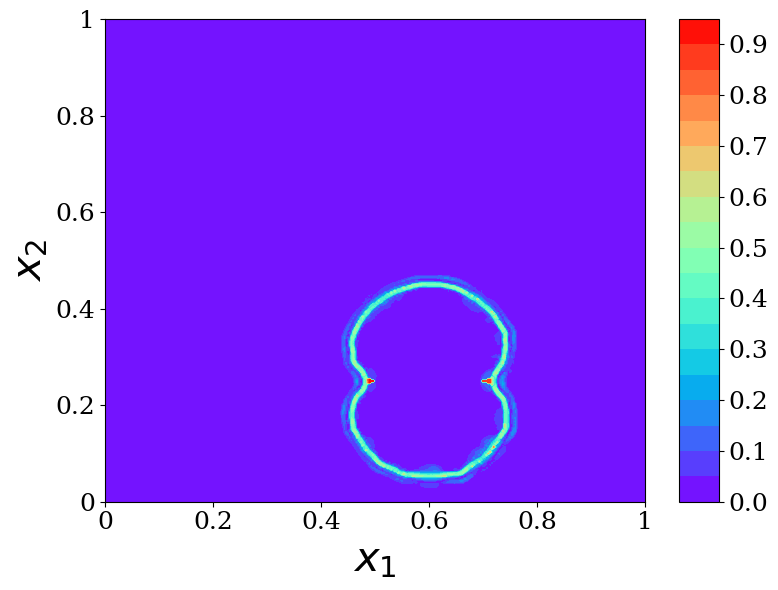

In [10]:
S_num=np.load("./noise=5%/S_test_num.npy")
# Create data
x = np.linspace(0, 1, 301)
y = np.linspace(0, 1, 301)
X, Y = np.meshgrid(x, y,indexing='ij')
samples=np.vstack((X.ravel(),Y.ravel())).T
center=np.array([[-0.06,0],[0.08,0]])
r=0.06
S_true=elegant_source(samples,[],[],[],[],center,r).reshape(len(x),len(y))
output_dictionary="./noise=5%/"
visual.draw(X,Y,S_true,output_dictionary,"S_true.pdf")
visual.draw(X,Y,S_num,output_dictionary,"S_num.pdf")
visual.draw(X,Y,np.abs(S_true-S_num),output_dictionary,"abs_S.pdf")